In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from matplotlib import rcParams
rcParams['font.family'] = 'Arial'
rcParams['pdf.fonttype'] = 42  # Use TrueType fonts
rcParams['ps.fonttype'] = 42 
rcParams['ps.useafm'] = True
rcParams['axes.linewidth'] = 0.5
rcParams['xtick.major.width'] = 0.5
rcParams['ytick.major.width'] = 0.5
rcParams['savefig.dpi'] = 300  # Ensure a high resolution

/tungstenfs/scratch/gfriedri/hubo/Software/python_env/catrace_cpu/lib/python3.10/site-packages/dataclasses_json/core.py:188: RuntimeWarning: 'NoneType' object value of non-optional type odors_learned detected when decoding DatasetConfig.
  warnings.warn(
/tungstenfs/scratch/gfriedri/hubo/Software/python_env/catrace_cpu/lib/python3.10/site-packages/dataclasses_json/core.py:188: RuntimeWarning: 'NoneType' object value of non-optional type odors_novel detected when decoding DatasetConfig.
  warnings.warn(
/tungstenfs/scratch/gfriedri/hubo/Software/python_env/catrace_cpu/lib/python3.10/site-packages/dataclasses_json/core.py:188: RuntimeWarning: 'NoneType' object value of non-optional type onsets detected when decoding DatasetConfig.
  warnings.warn(


Plotting average trace...
2021-07-15-DpOBEM-N2_Dp None
Computing distance matrices...
Plotting per condition...
{'ncol': 2, 'row_height': 1.35, 'col_width': 1.35, 'title_fontsize': 7, 'colorbar_fontsize': 6, 'ylabel_fontsize': 7, 'ylabels': None, 'ylabel_colors': None, 'cmap': 'turbo', 'clim': [8.191580139879832, 623.8422700219318], 'color_norm': None, 'cbar_interval': 200}
ylabel_ vfontsize: 7
ylabel_ vfontsize: 7
ylabel_ vfontsize: 7
ylabel_ vfontsize: 7
Plotting delta matrix...
clim: (-94.56862116579298, 94.56862116579298)
ylabel_ vfontsize: 7
Plotting vs statistics...


/tungstenfs/scratch/gfriedri/hubo/Ca_imaging/scripts/catrace/catrace/visualize.py:440: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_points = datadf.groupby([odor_name, condition_name], as_index=False, sort=False)[yname].mean()


Plotting per fish...


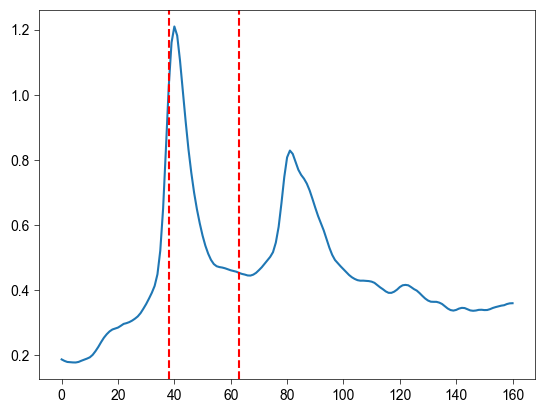

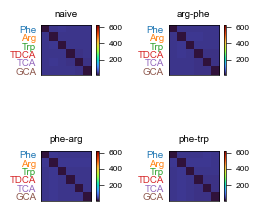

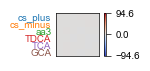

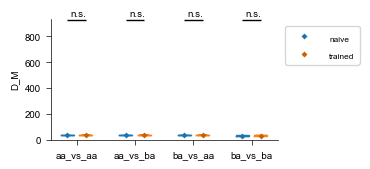

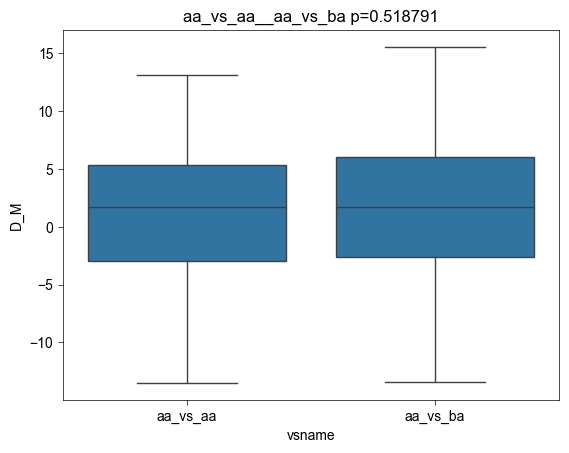

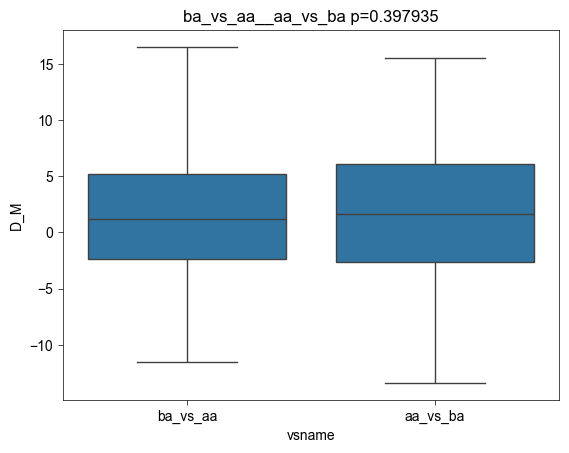

In [3]:
from catrace.run.run_distance import run_distance, RunDistanceParams, PlotDistanceParams, PlotPerCondMatParams, PlotMeanDeltaMatParams
from catrace.visualize import PlotBoxplotMultiOdorCondParams
# ylabels = ['A1', 'A2', 'A3', 'B1', 'B2', 'B3']
# ylabel_colors = ['#d25dd2', '#766acb', '#428cba', '#da866b', '#daa36b', '#879a73']
ylabels = None
ylabel_colors = None
plot_params = PlotDistanceParams(
    per_cond = PlotPerCondMatParams(
        row_height=1.35,
        col_width=1.35,
        title_fontsize=7,
        ylabel_fontsize=7,
        ylabel_colors = ylabel_colors,
        ylabels = ylabels,
        clim=(8.191580139879832, 623.8422700219318),
        cbar_interval=200
    ),
    mean_delta = PlotMeanDeltaMatParams(
        figsize=(1.6, 1.6),
        colorbar_fontsize = 7,
        ylabel_fontsize = 7,
        ylabels = ylabels,
        ylabel_colors = ylabel_colors,
        clim=(-94.56862116579298, 94.56862116579298)
    ),
    vs_measure = PlotBoxplotMultiOdorCondParams(
        figsize=(3.8, 1.8),
        label_fontsize=7,
        show_ns=True,
        box_linewidth=1,
        strip_size=0.5,
        mean_marker_size=1,
        pvalue_marker_xoffset=0.05,
        ylim=(0, 935.6151218959913)
    )
)
params = RunDistanceParams(
    config_file = '../juvenile_dataset_without14mm_phearg.json',
    assembly_name = '',
    time_window = [38, 63],#[38, 75],#[38, 63],#[58, 78],#[38, 63], #[37, 60], # [30, 68],
    sample_size = 70,#100
    metric = 'mahal',
    seed=124,
    do_normalize_simdf = False,
    do_reorder_cs=True,
    odor_orders = ['cs_plus', 'cs_minus', 'aa3', 'TDCA', 'TCA', 'GCA'],
    overwrite_computation = False,
    report_dir = '../../results/reports',
    summary_name = '',
    save_output = False,
    vs_same_ylim=[90, 370],
    reg=1e-5,
    do_plot_per_fish = False,
    plot_params = plot_params,
    parallelism = 20,
    num_repeats = 50,
    do_shuffle_manifold_pair_labels = True,
    shuffle_master_seed = 112
)


if params.assembly_name == '':
    assembly_label = 'all_neurons'
else:
    assembly_label = params.assembly_name
params.summary_name = f'distance_summary_{params.metric}_{assembly_label}_window{params.time_window[0]}to{params.time_window[1]}_norm{params.do_normalize_simdf}'

output_figs, test_results, concat_subsimdf = run_distance(params)

In [4]:
from os.path import join as pjoin
from catrace.for_paper import save_figure_for_paper
paper_fig_root_dir = '/tungstenfs/scratch/gfriedri/hubo/Dp_manifold/figures_for_paper'
dataset_name = 'juvenile'
analysis_name = 'distance'
paper_fig_dir = pjoin(paper_fig_root_dir, dataset_name, analysis_name)
window_tag = f'window{params.time_window[0]}to{params.time_window[1]}'
if params.do_shuffle_manifold_pair_labels:
    window_tag += f'_shuffled_seed{params.shuffle_master_seed}'


findfont: Font family ['Arial'] not found. Falling back to Helvetica.


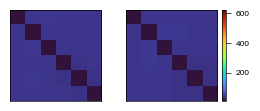

In [5]:
import copy
import os
import matplotlib
import matplotlib.colorbar as mcolorbar
from os.path import join as pjoin

def adjust_fig_per_cond(output_figs):
    fig_per_cond_copy = output_figs['fig_per_cond']
    ax = fig_per_cond_copy.get_axes()
    # Remove title for ax[0] and ax[1]
    ax[0].set_title('')
    ax[1].set_title('')
    # Delete y ticks on the second axes
    ax[0].set_yticks([])
    ax[1].set_yticks([])
    # Delete colorbar on the first axes
    fig = fig_per_cond_copy
    # Keep arg-phe
    fig.delaxes(fig.axes[2])
    fig.delaxes(fig.axes[5])
    fig.delaxes(fig.axes[2])
    fig.delaxes(fig.axes[4])
    fig.delaxes(fig.axes[2])
    fig_per_cond_copy.tight_layout()
    return fig_per_cond_copy

fig_per_cond_copy = adjust_fig_per_cond(output_figs)
save_figure_for_paper(fig_per_cond_copy, f'{dataset_name}_{params.metric}_distance_per_cond_{window_tag}', paper_fig_dir, save_eps=True)
fig_per_cond_copy

findfont: Font family ['Arial'] not found. Falling back to Helvetica.


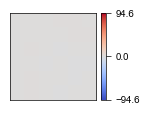

In [6]:
def adjust_fig_delta(output_figs):
    fig_delta_copy = output_figs['fig_delta']
    ax = fig_delta_copy.get_axes()
    ax[0].set_yticks([])
    fig_delta_copy.tight_layout()
    return fig_delta_copy

fig_delta_copy = adjust_fig_delta(output_figs)
save_figure_for_paper(fig_delta_copy, f'{dataset_name}_{params.metric}_mean_delta_{window_tag}', paper_fig_dir, save_eps=True)
fig_delta_copy

/tmp/ipykernel_3677913/271405019.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([xtick_mapping[xtick.get_text()] for xtick in xticklabels], fontsize=tick_fontsize)


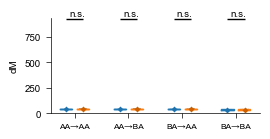

In [7]:
def adjust_fig_multi_vs(output_figs):
    label_fontsize = 7
    tick_fontsize = 6
    fig = output_figs['fig_multi_vs']
    ax = fig.get_axes()[0]
    # Remove legend
    if ax.get_legend() is not None:
        ax.get_legend().remove()
    # Rest figure size
    fig.set_size_inches(2.8, 1.5)
    # Change ylabel
    ylabel = ax.get_ylabel()
    if ylabel == 'D_M':
        ax.set_ylabel('dM', fontsize=label_fontsize)
    elif ylabel == 'center D_E':
        ax.set_ylabel('dE', fontsize=label_fontsize)

    xticklabels = ax.get_xticklabels()
    if ylabel == 'D_M':
        xtick_mapping = {'aa_vs_aa': 'AA→AA', 'aa_vs_ba': 'AA→BA', 'ba_vs_ba': 'BA→BA', 'ba_vs_aa': 'BA→AA'}
    elif ylabel == 'center D_E':
        xtick_mapping = {'aa_vs_aa': 'AA↔AA', 'aa_vs_ba': 'AA↔BA', 'ba_vs_ba': 'BA↔BA', 'ba_vs_aa': 'BA↔AA'}
    else:
        xtick_mapping = None
    if xtick_mapping is not None:
        ax.set_xticklabels([xtick_mapping[xtick.get_text()] for xtick in xticklabels], fontsize=tick_fontsize)
    fig.tight_layout()
    return fig
fig = adjust_fig_multi_vs(output_figs)
save_figure_for_paper(fig, f'{dataset_name}_{params.metric}_multi_vs_{window_tag}', paper_fig_dir)
fig


In [8]:
from catrace.stats import format_test_results_multi_odor_two_cond
sentence = format_test_results_multi_odor_two_cond(test_results)
sentence = sentence.replace('aa_vs_aa', 'AvsA').replace('aa_vs_ba', 'AvsB').replace('ba_vs_aa', 'BvsA').replace('ba_vs_ba', 'BvsB')
print(sentence)

For AvsA, Comparing naive (mean = 39.19 ± 1.459, n = 36) vs trained (mean = 39.59 ± 2.315, n = 150): Mann–Whitney U test, U = 2319.00, P = 0.190. For AvsB, Comparing naive (mean = 38.45 ± 1.473, n = 54) vs trained (mean = 39.03 ± 2.344, n = 225): Mann–Whitney U test, U = 5064.00, P = 0.058. For BvsA, Comparing naive (mean = 38.62 ± 1.527, n = 54) vs trained (mean = 39.04 ± 2.295, n = 225): Mann–Whitney U test, U = 5382.00, P = 0.193. For BvsB, Comparing naive (mean = 36.67 ± 1.510, n = 36) vs trained (mean = 36.77 ± 1.954, n = 150): Mann–Whitney U test, U = 2554.00, P = 0.616.


/tungstenfs/scratch/gfriedri/hubo/Software/python_env/catrace_cpu/lib/python3.10/site-packages/dataclasses_json/core.py:188: RuntimeWarning: 'NoneType' object value of non-optional type odors_learned detected when decoding DatasetConfig.
  warnings.warn(
/tungstenfs/scratch/gfriedri/hubo/Software/python_env/catrace_cpu/lib/python3.10/site-packages/dataclasses_json/core.py:188: RuntimeWarning: 'NoneType' object value of non-optional type odors_novel detected when decoding DatasetConfig.
  warnings.warn(
/tungstenfs/scratch/gfriedri/hubo/Software/python_env/catrace_cpu/lib/python3.10/site-packages/dataclasses_json/core.py:188: RuntimeWarning: 'NoneType' object value of non-optional type onsets detected when decoding DatasetConfig.
  warnings.warn(


Plotting average trace...
2021-07-15-DpOBEM-N2_Dp None
Computing distance matrices...
Plotting per condition...
{'ncol': 2, 'row_height': 1.36, 'col_width': 1.36, 'title_fontsize': 7, 'colorbar_fontsize': 6, 'ylabel_fontsize': 7, 'ylabels': None, 'ylabel_colors': ['#d25dd2', '#766acb', '#428cba', '#da866b', '#daa36b', '#879a73'], 'cmap': 'turbo', 'clim': [0.0, 10.789918901980275], 'color_norm': None, 'cbar_interval': 2.0}
ylabel_ vfontsize: 7
ylabel_ vfontsize: 7
ylabel_ vfontsize: 7
ylabel_ vfontsize: 7
Plotting delta matrix...
clim: (-1.8979229501995356, 1.8979229501995356)
ylabel_ vfontsize: 7
Plotting vs statistics...


/tungstenfs/scratch/gfriedri/hubo/Ca_imaging/scripts/catrace/catrace/visualize.py:440: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_points = datadf.groupby([odor_name, condition_name], as_index=False, sort=False)[yname].mean()


Plotting per fish...


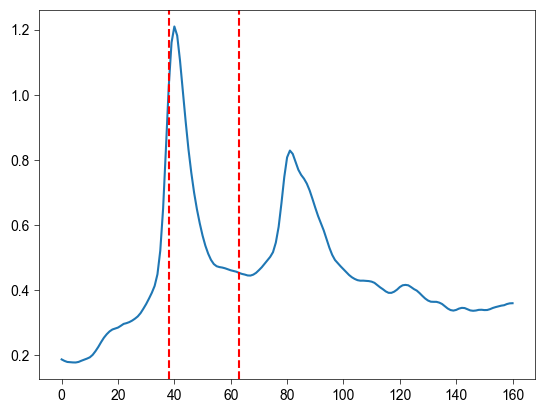

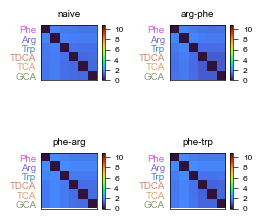

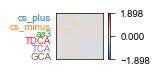

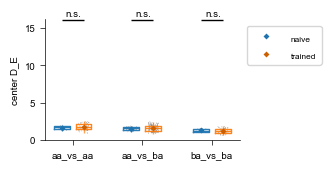

In [9]:
plot_params = PlotDistanceParams(
    per_cond = PlotPerCondMatParams(
        row_height=1.36,
        col_width=1.36,
        title_fontsize=7,
        ylabel_fontsize=7,
        ylabel_colors = ['#d25dd2', '#766acb', '#428cba', '#da866b', '#daa36b', '#879a73'],
        clim=(0.0, 10.789918901980275),
        cbar_interval=2.0,
    ),
    mean_delta = PlotMeanDeltaMatParams(
        figsize=(1.7, 1.7),
        colorbar_fontsize = 7,
        ylabel_fontsize = 7,
        ylabels = ylabels,
        ylabel_colors = ylabel_colors,
        clim=(-1.8979229501995356, 1.8979229501995356),
    ),
    vs_measure = PlotBoxplotMultiOdorCondParams(
        figsize=(3.5, 1.8),
        label_fontsize=7,
        show_ns=True,
        box_linewidth=1,
        strip_size=0.5,
        mean_marker_size=1,
        pvalue_marker_xoffset=0.05,
        ylim=(0, 16.221725749658447),
    ))
config_file = '../juvenile_dataset_without14mm_phearg.json'
from catrace.dataset import load_dataset_config
dsconfig = load_dataset_config(config_file)
params = RunDistanceParams(
    config_file = config_file,
    assembly_name = '',
    time_window = [38, 63],#[38, 75],#[38, 63],#[58, 78],#[38, 63],#[37, 60],#[37, 52], #[30, 68],
    sample_size = 70,#100,
    metric = 'center_euclidean',
    seed=124,
    do_normalize_simdf = False,
    do_reorder_cs=True,
    odor_orders = ['cs_plus', 'cs_minus', 'aa3', 'TDCA', 'TCA', 'GCA'],
    overwrite_computation = False,
    report_dir = '../../results/reports',
    summary_name = '',
    save_output = False,
    vs_same_ylim=[0.5, 2.3],
    reg=1e-5,
    do_plot_per_fish = False,
    plot_params = plot_params,
    vsdict = {'aa_vs_aa': (dsconfig.odors_aa, dsconfig.odors_aa),
            'aa_vs_ba': (dsconfig.odors_aa, dsconfig.odors_ba),
            'ba_vs_ba': (dsconfig.odors_ba, dsconfig.odors_ba)},
    parallelism = 20,
    do_shuffle_manifold_pair_labels = True,
    shuffle_master_seed = 112,
    num_repeats = 50)    


if params.assembly_name == '':
    assembly_label = 'all_neurons'
else:
    assembly_label = params.assembly_name
params.summary_name = f'distance_summary_{params.metric}_{assembly_label}_window{params.time_window[0]}to{params.time_window[1]}_norm{params.do_normalize_simdf}'

output_figs, test_results, concat_subsimdf = run_distance(params)

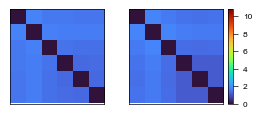

In [10]:
fig_per_cond_copy = adjust_fig_per_cond(output_figs)
save_figure_for_paper(fig_per_cond_copy, f'{dataset_name}_{params.metric}_distance_per_cond_{window_tag}', paper_fig_dir, save_eps=True)
fig_per_cond_copy


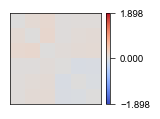

In [11]:
fig_delta_copy = adjust_fig_delta(output_figs)
save_figure_for_paper(fig_delta_copy, f'{dataset_name}_{params.metric}_mean_delta_{window_tag}', paper_fig_dir, save_eps=True)
fig_delta_copy

/tmp/ipykernel_3677913/1942901185.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([xtick_mapping[xtick.get_text()] for xtick in xticklabels], fontsize=tick_fontsize)


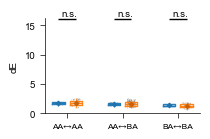

In [12]:
def adjust_fig_multi_vs(output_figs):
    label_fontsize = 7
    tick_fontsize = 6
    fig = output_figs['fig_multi_vs']
    ax = fig.get_axes()[0]
    # Remove legend
    if ax.get_legend() is not None:
        ax.get_legend().remove()
    # Rest figure size
    fig.set_size_inches(2.2, 1.5)
    # Change ylabel
    ylabel = ax.get_ylabel()
    if ylabel == 'D_M':
        ax.set_ylabel('dM', fontsize=label_fontsize)
    elif ylabel == 'center D_E':
        ax.set_ylabel('dE', fontsize=label_fontsize)

    xticklabels = ax.get_xticklabels()
    if ylabel == 'D_M':
        xtick_mapping = {'aa_vs_aa': 'AA→AA', 'aa_vs_ba': 'AA→BA', 'ba_vs_ba': 'BA→BA', 'ba_vs_aa': 'BA→AA'}
    elif ylabel == 'center D_E':
        xtick_mapping = {'aa_vs_aa': 'AA↔AA', 'aa_vs_ba': 'AA↔BA', 'ba_vs_ba': 'BA↔BA', 'ba_vs_aa': 'BA↔AA'}
    else:
        xtick_mapping = None
    if xtick_mapping is not None:
        ax.set_xticklabels([xtick_mapping[xtick.get_text()] for xtick in xticklabels], fontsize=tick_fontsize)
    fig.tight_layout()
    return fig
fig = adjust_fig_multi_vs(output_figs)
save_figure_for_paper(fig, f'{dataset_name}_{params.metric}_multi_vs_{window_tag}', paper_fig_dir)
fig


In [13]:
from catrace.stats import format_test_results_multi_odor_two_cond
sentence = format_test_results_multi_odor_two_cond(test_results)
# Replace aa_vs_aa with AvsA, aa_vs_ba with AvsB, ba_vs_aa with BvsA, ba_vs_ba with BvsB
sentence = sentence.replace('aa_vs_aa', 'AvsA').replace('aa_vs_ba', 'AvsB').replace('ba_vs_aa', 'BvsA').replace('ba_vs_ba', 'BvsB')
print(sentence)

For AvsA, Comparing naive (mean = 1.674 ± 0.2188, n = 18) vs trained (mean = 1.803 ± 0.3983, n = 75): Mann–Whitney U test, U = 542.00, P = 0.198. For AvsB, Comparing naive (mean = 1.555 ± 0.2098, n = 54) vs trained (mean = 1.608 ± 0.3766, n = 225): Mann–Whitney U test, U = 5730.00, P = 0.518. For BvsB, Comparing naive (mean = 1.331 ± 0.1912, n = 18) vs trained (mean = 1.265 ± 0.3167, n = 75): Mann–Whitney U test, U = 754.00, P = 0.445.
